In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

import plotly.express as px

%matplotlib inline

In [2]:
df = pd.read_excel('marketing_campaign1.xlsx')

df1 = df.copy()

print(df.head())

       ID  Year_Birth   Education Marital_Status   Income  Kidhome  Teenhome  \
0  5524.0      1957.0  Graduation         Single  58138.0      0.0       0.0   
1  2174.0      1954.0  Graduation         Single  46344.0      1.0       1.0   
2  4141.0      1965.0  Graduation       Together  71613.0      0.0       0.0   
3  6182.0      1984.0  Graduation       Together  26646.0      1.0       0.0   
4  5324.0      1981.0         PhD        Married  58293.0      1.0       0.0   

  Dt_Customer  Recency  MntWines  ...  NumWebVisitsMonth  AcceptedCmp3  \
0  2012-09-04     58.0     635.0  ...                7.0           0.0   
1  2014-03-08     38.0      11.0  ...                5.0           0.0   
2  2013-08-21     26.0     426.0  ...                4.0           0.0   
3  2014-02-10     26.0      11.0  ...                6.0           0.0   
4  2014-01-19     94.0     173.0  ...                5.0           0.0   

   AcceptedCmp4  AcceptedCmp5  AcceptedCmp1  AcceptedCmp2  Complain  \
0  

In [3]:
df.shape

(2240, 29)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2240 non-null   float64       
 1   Year_Birth           2240 non-null   float64       
 2   Education            2240 non-null   object        
 3   Marital_Status       2240 non-null   object        
 4   Income               2216 non-null   float64       
 5   Kidhome              2240 non-null   float64       
 6   Teenhome             2240 non-null   float64       
 7   Dt_Customer          2240 non-null   datetime64[ns]
 8   Recency              2240 non-null   float64       
 9   MntWines             2240 non-null   float64       
 10  MntFruits            2240 non-null   float64       
 11  MntMeatProducts      2240 non-null   float64       
 12  MntFishProducts      2240 non-null   float64       
 13  MntSweetProducts     2240 non-nul

In [5]:
df.duplicated().sum()

0

In [6]:
df.isnull().sum()

ID                      0
Year_Birth              0
Education               0
Marital_Status          0
Income                 24
Kidhome                 0
Teenhome                0
Dt_Customer             0
Recency                 0
MntWines                0
MntFruits               0
MntMeatProducts         0
MntFishProducts         0
MntSweetProducts        0
MntGoldProds            0
NumDealsPurchases       0
NumWebPurchases         0
NumCatalogPurchases     0
NumStorePurchases       0
NumWebVisitsMonth       0
AcceptedCmp3            0
AcceptedCmp4            0
AcceptedCmp5            0
AcceptedCmp1            0
AcceptedCmp2            0
Complain                0
Z_CostContact           0
Z_Revenue               0
Response                0
dtype: int64

In [7]:
missing_values = df.isna().sum().to_dict()
missing_values_df = pd.DataFrame(list(missing_values.items()), columns=['Column', 'Missing_Values'])

fig = px.bar(missing_values_df,
       x = 'Column',
       y = 'Missing_Values',
       template = 'plotly_white',
       title = 'Missing Values')
fig.show()

In [8]:
df.describe()

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
count,2240.000000,2240.000000,2216.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,...,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.0,2240.0,2240.000000
mean,5592.159821,1968.805804,52247.251354,0.444196,0.506250,49.109375,303.935714,26.302232,166.950000,37.525446,...,5.316518,0.072768,0.074554,0.072768,0.064286,0.013393,0.009375,3.0,11.0,0.149107
std,3246.662198,11.984069,25173.076661,0.538398,0.544538,28.962453,336.597393,39.773434,225.715373,54.628979,...,2.426645,0.259813,0.262728,0.259813,0.245316,0.114976,0.096391,0.0,0.0,0.356274
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
25%,2828.250000,1959.000000,35303.000000,0.000000,0.000000,24.000000,23.750000,1.000000,16.000000,3.000000,...,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,173.500000,8.000000,67.000000,12.000000,...,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
75%,8427.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,504.250000,33.000000,232.000000,50.000000,...,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.0,11.0,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3.0,11.0,1.000000


In [9]:
df['Income'].fillna(df['Income'].mean(), inplace=True)
df1['Income'].fillna(df1['Income'].mean(), inplace=True)

In [10]:
df.isnull().sum()

ID                     0
Year_Birth             0
Education              0
Marital_Status         0
Income                 0
Kidhome                0
Teenhome               0
Dt_Customer            0
Recency                0
MntWines               0
MntFruits              0
MntMeatProducts        0
MntFishProducts        0
MntSweetProducts       0
MntGoldProds           0
NumDealsPurchases      0
NumWebPurchases        0
NumCatalogPurchases    0
NumStorePurchases      0
NumWebVisitsMonth      0
AcceptedCmp3           0
AcceptedCmp4           0
AcceptedCmp5           0
AcceptedCmp1           0
AcceptedCmp2           0
Complain               0
Z_CostContact          0
Z_Revenue              0
Response               0
dtype: int64

Text(0.5, 1.0, 'Income')

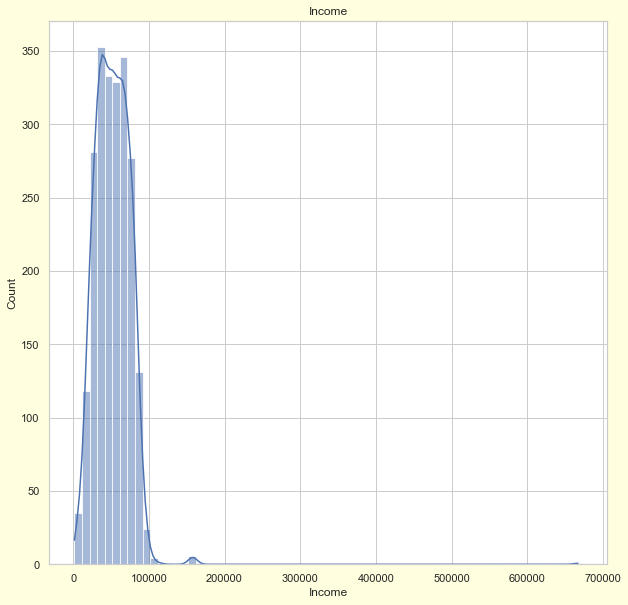

In [11]:
plt.figure(figsize=(10,10), facecolor='lightyellow')
sns.set(style='whitegrid')
ax = sns.histplot(data=df, x='Income', binwidth=10000, kde=True)
ax.set_title('Income')

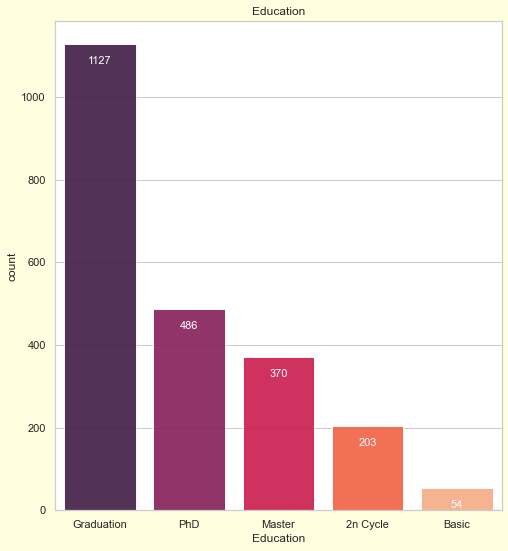

In [12]:
plt.figure(figsize=(8, 9), facecolor='lightyellow')
sns.set(style='whitegrid')
ax = sns.countplot(data=df, x='Education', saturation=1, alpha=0.9, palette='rocket', order=df['Education'].value_counts().index)
ax.set_title('Education')
for p in ax.patches:
 ax.annotate(f'\n{p.get_height()}', (p.get_x()+0.4, p.get_height()), ha='center', va='top', color='white', size=11)
plt.show()

Text(-49, 0, '680816.0')

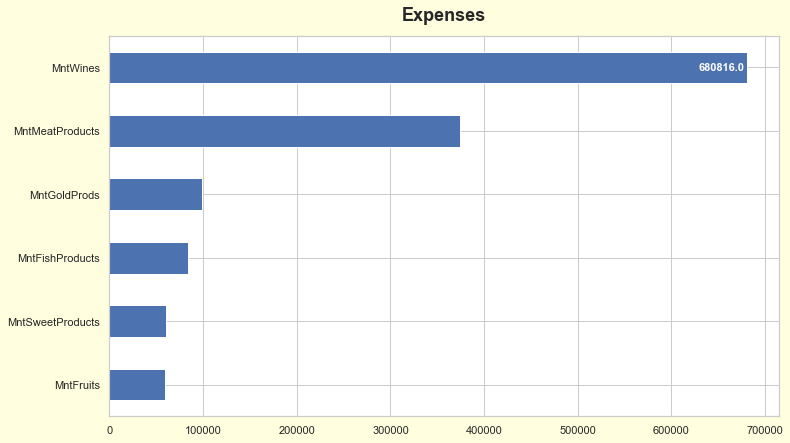

In [13]:
plt.figure(figsize=(12,7), facecolor='lightyellow')
ax = df[['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum().sort_values(ascending=True).plot(kind='barh')
plt.title('Expenses', pad=15, fontsize=18, fontweight='semibold')
rects = ax.patches
for rect in rects:
 x_value = rect.get_width()
 y_value = rect.get_y() + rect.get_height() / 2
plt.annotate('{}'.format(x_value), (x_value, y_value), xytext=(-49, 0),
textcoords='offset points', va='center', ha='left', color = 'white', fontsize=11, fontweight='semibold')

Text(-50, 0, '334.0')

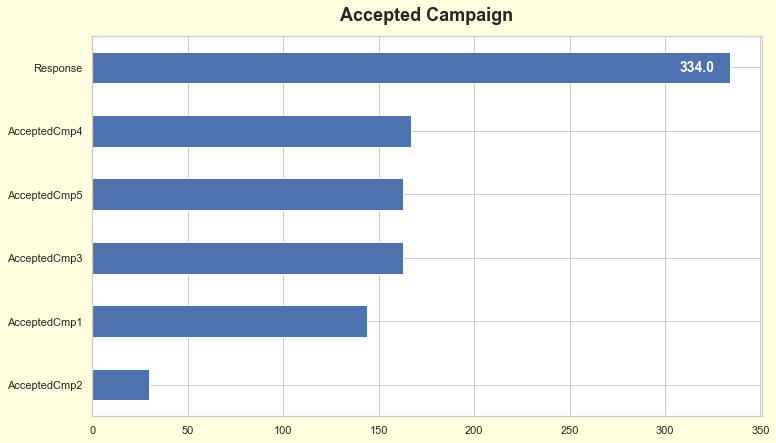

In [14]:
plt.figure(figsize=(12,7), facecolor='lightyellow')
ax = df[['AcceptedCmp1', 'AcceptedCmp2', 'AcceptedCmp3', 'AcceptedCmp4','AcceptedCmp5', 'Response']].sum().sort_values(ascending=True).plot(kind='barh')
plt.title('Accepted Campaign', pad=15, fontsize=18, fontweight='semibold')
rects = ax.patches
for rect in rects:
 x_value = rect.get_width()
y_value = rect.get_y() + rect.get_height() / 2
plt.annotate('{}'.format(x_value), (x_value, y_value), xytext=(-50, 0),
textcoords='offset points', va='center', ha='left', color = 'white', fontsize=14, fontweight='semibold')

In [15]:
df.nunique()

ID                     2240
Year_Birth               59
Education                 5
Marital_Status            8
Income                 1975
Kidhome                   3
Teenhome                  3
Dt_Customer             663
Recency                 100
MntWines                776
MntFruits               158
MntMeatProducts         558
MntFishProducts         182
MntSweetProducts        177
MntGoldProds            213
NumDealsPurchases        15
NumWebPurchases          15
NumCatalogPurchases      14
NumStorePurchases        14
NumWebVisitsMonth        16
AcceptedCmp3              2
AcceptedCmp4              2
AcceptedCmp5              2
AcceptedCmp1              2
AcceptedCmp2              2
Complain                  2
Z_CostContact             1
Z_Revenue                 1
Response                  2
dtype: int64

 "Z_CostContact" and "Z_Revenue" have same value in all the rows that's why they are not going to contribute anything in the model building. So we can drop them.


In [16]:
df=df.drop(columns=["Z_CostContact", "Z_Revenue"],axis=1)


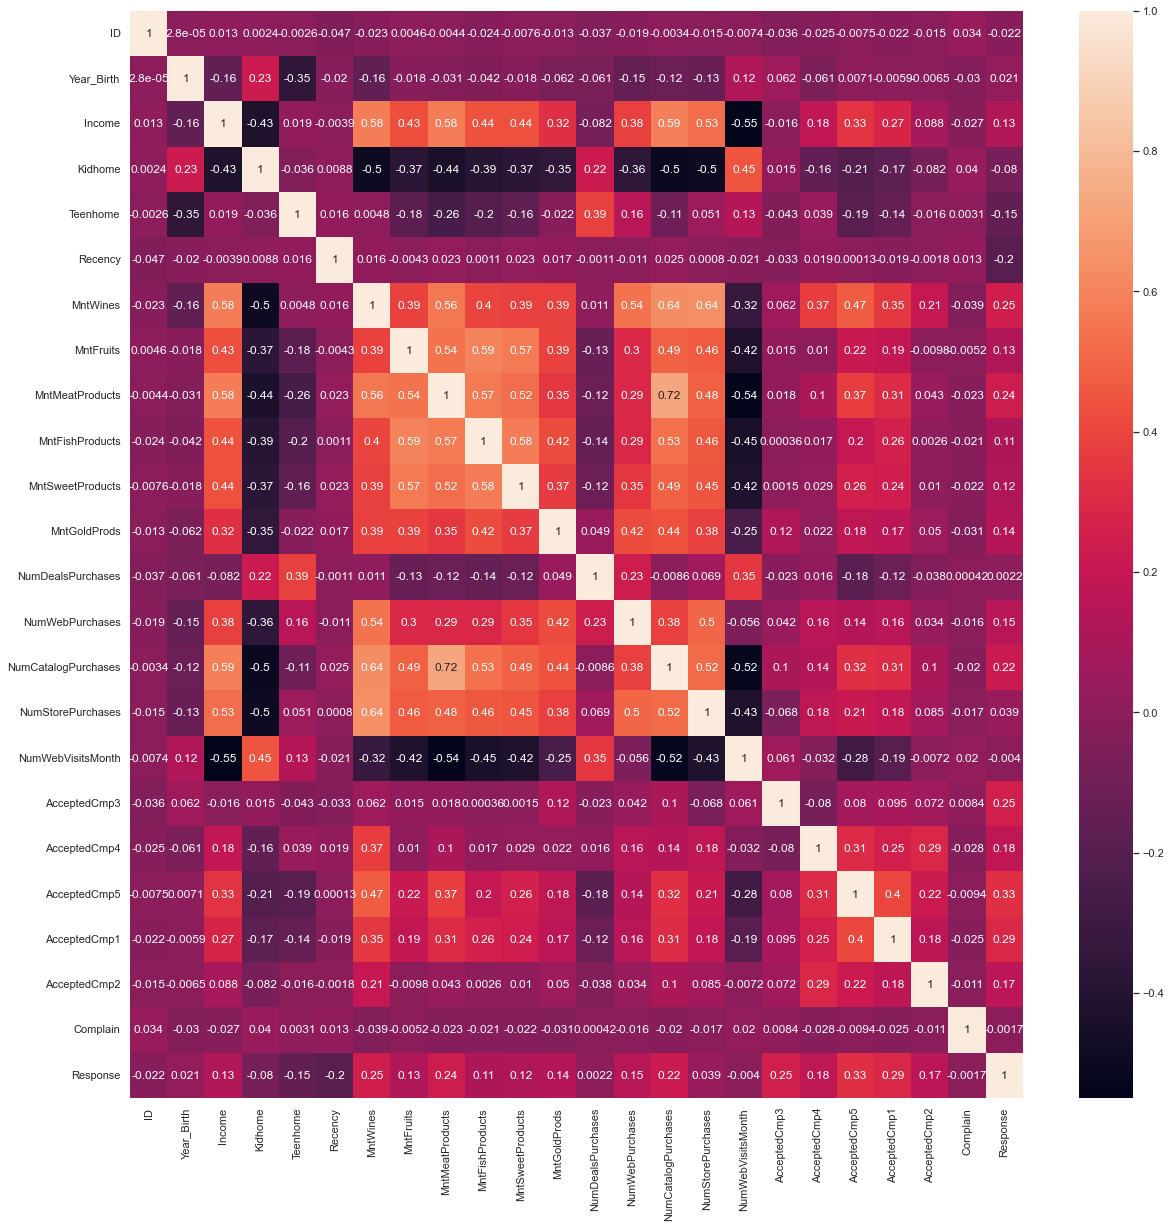

In [17]:
plt.figure(figsize=(20,20))
sns.heatmap(df.corr(), annot=True)
plt.show()

In [18]:
df['Marital_Status'].value_counts()

Married     864
Together    580
Single      480
Divorced    232
Widow        77
Alone         3
Absurd        2
YOLO          2
Name: Marital_Status, dtype: int64

In [19]:
df['Marital_Status'] = df['Marital_Status'].replace(['Married', 'Together'],'relationship')
df['Marital_Status'] = df['Marital_Status'].replace(['Divorced', 'Widow', 'Alone', 'YOLO', 'Absurd'],'Single')

In [20]:
df['Marital_Status'].value_counts()


relationship    1444
Single           796
Name: Marital_Status, dtype: int64

In [21]:
# Combining different dataframe into a single column to reduce the number of dimension
df['Kids'] = df['Kidhome'] + df['Teenhome']
df['Expenses'] = df['MntWines'] + df['MntFruits'] + df['MntMeatProducts'] + df['MntFishProducts'] + df['MntSweetProducts'] + df['MntGoldProds']
df['TotalAcceptedCmp'] = df['AcceptedCmp1'] + df['AcceptedCmp2'] + df['AcceptedCmp3'] + df['AcceptedCmp4'] + df['AcceptedCmp5'] + df['Response']
df['NumTotalPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases'] + df['NumDealsPurchases']

In [22]:
# Deleting some column to reduce dimension and complexity of model

col_del = ["AcceptedCmp1" , "AcceptedCmp2", "AcceptedCmp3" , "AcceptedCmp4","AcceptedCmp5", "Response","NumWebVisitsMonth", "NumWebPurchases","NumCatalogPurchases","NumStorePurchases","NumDealsPurchases" , "Kidhome", "Teenhome","MntWines", "MntFruits", "MntMeatProducts", "MntFishProducts", "MntSweetProducts", "MntGoldProds"]
df=df.drop(columns=col_del,axis=1)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,Complain,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases
0,5524.0,1957.0,Graduation,Single,58138.0,2012-09-04,58.0,0.0,0.0,1617.0,1.0,25.0
1,2174.0,1954.0,Graduation,Single,46344.0,2014-03-08,38.0,0.0,2.0,27.0,0.0,6.0
2,4141.0,1965.0,Graduation,relationship,71613.0,2013-08-21,26.0,0.0,0.0,776.0,0.0,21.0
3,6182.0,1984.0,Graduation,relationship,26646.0,2014-02-10,26.0,0.0,1.0,53.0,0.0,8.0
4,5324.0,1981.0,PhD,relationship,58293.0,2014-01-19,94.0,0.0,1.0,422.0,0.0,19.0


In [23]:
df['Education'].value_counts()

Graduation    1127
PhD            486
Master         370
2n Cycle       203
Basic           54
Name: Education, dtype: int64

In [24]:
# Changing category into UG and PG only

df['Education'] = df['Education'].replace(['PhD','2n Cycle','Graduation', 'Master'],'PG')
df['Education'] = df['Education'].replace(['Basic'], 'UG')

In [25]:
# Adding a column "Age" in the dataframe

df['Age'] = 2015 - df["Year_Birth"]

In [26]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,Complain,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases,Age
0,5524.0,1957.0,PG,Single,58138.0,2012-09-04,58.0,0.0,0.0,1617.0,1.0,25.0,58.0
1,2174.0,1954.0,PG,Single,46344.0,2014-03-08,38.0,0.0,2.0,27.0,0.0,6.0,61.0
2,4141.0,1965.0,PG,relationship,71613.0,2013-08-21,26.0,0.0,0.0,776.0,0.0,21.0,50.0
3,6182.0,1984.0,PG,relationship,26646.0,2014-02-10,26.0,0.0,1.0,53.0,0.0,8.0,31.0
4,5324.0,1981.0,PG,relationship,58293.0,2014-01-19,94.0,0.0,1.0,422.0,0.0,19.0,34.0


In [27]:
# Number of days a customer was engaged with company

# Changing Dt_customer into timestamp format
df['Dt_Customer'] = pd.to_datetime(df.Dt_Customer)
df['first_day'] = '01-01-2015'
df['first_day'] = pd.to_datetime(df.first_day)
df['day_engaged'] = (df['first_day'] - df['Dt_Customer']).dt.days

In [28]:
df

,ID,Year_Birth,Education,Marital_Status,Income,Dt_Customer,Recency,Complain,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases,Age,first_day,day_engaged
0,5524.0,1957.0,PG,Single,58138.0,2012-09-04,58.0,0.0,0.0,1617.0,1.0,25.0,58.0,2015-01-01,849
1,2174.0,1954.0,PG,Single,46344.0,2014-03-08,38.0,0.0,2.0,27.0,0.0,6.0,61.0,2015-01-01,299
2,4141.0,1965.0,PG,relationship,71613.0,2013-08-21,26.0,0.0,0.0,776.0,0.0,21.0,50.0,2015-01-01,498
3,6182.0,1984.0,PG,relationship,26646.0,2014-02-10,26.0,0.0,1.0,53.0,0.0,8.0,31.0,2015-01-01,325
4,5324.0,1981.0,PG,relationship,58293.0,2014-01-19,94.0,0.0,1.0,422.0,0.0,19.0,34.0,2015-01-01,347
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,10870.0,1967.0,PG,relationship,61223.0,2013-06-13,46.0,0.0,1.0,1341.0,0.0,18.0,48.0,2015-01-01,567
2236,4001.0,1946.0,PG,relationship,64014.0,2014-06-10,56.0,0.0,3.0,444.0,1.0,22.0,69.0,2015-01-01,205
2237,7270.0,1981.0,PG,Single,56981.0,2014-01-25,91.0,0.0,0.0,1241.0,1.0,19.0,34.0,2015-01-01,341
2238,8235.0,1956.0,PG,relationship,69245.0,2014-01-24,8.0,0.0,1.0,843.0,0.0,23.0,59.0,2015-01-01,342


In [29]:
# "Recency", "Complain" columns were dropped before

df=df.drop(columns=["ID", "Dt_Customer", "first_day", "Year_Birth", "Dt_Customer"],axis=1)
df.shape

(2240, 11)

In [30]:
fig = px.histogram (df, x = "Expenses",  facet_row = "Marital_Status",  template = 'plotly')
fig.show ()

In [31]:
fig = px.histogram (df, x = "NumTotalPurchases",  facet_row = "Education",  template = 'plotly')
fig.show ()

In [32]:
fig = px.histogram (df, x = "Age",  facet_row = "Marital_Status",  template = 'plotly')
fig.show ()

In [33]:
fig = px.histogram (df, x = "Income",  facet_row = "Marital_Status",  template = 'plotly')
fig.show ()

In [34]:
df.describe()

,Income,Recency,Complain,Kids,Expenses,TotalAcceptedCmp,NumTotalPurchases,Age,day_engaged
count,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000,2240.000000
mean,52247.251354,49.109375,0.009375,0.950446,605.798214,0.446875,14.862054,46.194196,539.582143
std,25037.797168,28.962453,0.096391,0.751803,602.249288,0.890543,7.677173,11.984069,202.122512
min,1730.000000,0.000000,0.000000,0.000000,5.000000,0.000000,0.000000,19.000000,186.000000
25%,35538.750000,24.000000,0.000000,0.000000,68.750000,0.000000,8.000000,38.000000,366.750000
50%,51741.500000,49.000000,0.000000,1.000000,396.000000,0.000000,15.000000,45.000000,541.500000
75%,68289.750000,74.000000,0.000000,1.000000,1045.500000,1.000000,21.000000,56.000000,715.000000
max,666666.000000,99.000000,1.000000,3.000000,2525.000000,5.000000,44.000000,122.000000,885.000000


<AxesSubplot:>

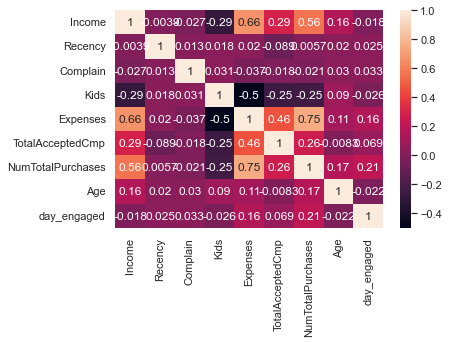

In [35]:
sns.heatmap(df.corr(), annot=True)

In [36]:
df.columns

Index(['Education', 'Marital_Status', 'Income', 'Recency', 'Complain', 'Kids',
       'Expenses', 'TotalAcceptedCmp', 'NumTotalPurchases', 'Age',
       'day_engaged'],
      dtype='object')

In [37]:
df1.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response'],
      dtype='object')

In [38]:
#removing outliers
df1['Age'] = df['Age']

df = df[df.Age < 100]
df = df[df.Income < 120000]

df1 = df1[df1.Age < 100]
df1 = df1[df1.Income < 120000]

## Feature Engineering

### 1. Feature Selection

In [39]:
# As we dont have dependent or target feature we cannot perform univariate
# feature selection or recursive feature elimination

# But we can eliminate the features based on correlation and domain knowledge

# ID column is not going to contribute in deciding clusters

# From EDA we see that Z_CostContact, Z_Revenue contains only single value so the
# feature can be dropped

# Also from EDA we concluded that Dt_customer can be used as days engaged and
# drop original feature

# And from Year_Birth we get new feature age and drop the original one

# Also Kidhome and Teenhome can be combined to single column which is Kids

# Education which contains categorical values is remodified which contains only
# two categories which are UG and PG

# Marital_Status column is also remodified with single and relationship as
# categories

data = df.copy()

df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2229 entries, 0 to 2239
Data columns (total 30 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   ID                   2229 non-null   float64       
 1   Year_Birth           2229 non-null   float64       
 2   Education            2229 non-null   object        
 3   Marital_Status       2229 non-null   object        
 4   Income               2229 non-null   float64       
 5   Kidhome              2229 non-null   float64       
 6   Teenhome             2229 non-null   float64       
 7   Dt_Customer          2229 non-null   datetime64[ns]
 8   Recency              2229 non-null   float64       
 9   MntWines             2229 non-null   float64       
 10  MntFruits            2229 non-null   float64       
 11  MntMeatProducts      2229 non-null   float64       
 12  MntFishProducts      2229 non-null   float64       
 13  MntSweetProducts     2229 non-nul

In [40]:
df1.drop(columns=["ID", "Dt_Customer", "Year_Birth", "Kidhome", "Teenhome", "Z_CostContact", "Z_Revenue", "Education", "Marital_Status"],axis=1, inplace=True)

In [41]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2229 entries, 0 to 2239
Data columns (total 11 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Education          2229 non-null   object 
 1   Marital_Status     2229 non-null   object 
 2   Income             2229 non-null   float64
 3   Recency            2229 non-null   float64
 4   Complain           2229 non-null   float64
 5   Kids               2229 non-null   float64
 6   Expenses           2229 non-null   float64
 7   TotalAcceptedCmp   2229 non-null   float64
 8   NumTotalPurchases  2229 non-null   float64
 9   Age                2229 non-null   float64
 10  day_engaged        2229 non-null   int64  
dtypes: float64(8), int64(1), object(2)
memory usage: 209.0+ KB


In [42]:
df.drop(columns=["Recency", "Complain", "TotalAcceptedCmp"],axis=1, inplace=True)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2229 entries, 0 to 2239
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Education          2229 non-null   object 
 1   Marital_Status     2229 non-null   object 
 2   Income             2229 non-null   float64
 3   Kids               2229 non-null   float64
 4   Expenses           2229 non-null   float64
 5   NumTotalPurchases  2229 non-null   float64
 6   Age                2229 non-null   float64
 7   day_engaged        2229 non-null   int64  
dtypes: float64(5), int64(1), object(2)
memory usage: 156.7+ KB


In [44]:
modified_features = ['Education', 'Marital_Status', 'Kids', 'Age', 'day_engaged']

for feature in modified_features:
  df1[feature] = df[feature]

columns = df1.columns

df1.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Education,Marital_Status,Kids,day_engaged
0,58138.0,58.0,635.0,88.0,546.0,172.0,88.0,88.0,3.0,8.0,...,0.0,0.0,0.0,0.0,1.0,58.0,PG,Single,0.0,849
1,46344.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,61.0,PG,Single,2.0,299
2,71613.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,...,0.0,0.0,0.0,0.0,0.0,50.0,PG,relationship,0.0,498
3,26646.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,31.0,PG,relationship,1.0,325
4,58293.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,...,0.0,0.0,0.0,0.0,0.0,34.0,PG,relationship,1.0,347


In [45]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 2229 entries, 0 to 2239
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Income               2229 non-null   float64
 1   Recency              2229 non-null   float64
 2   MntWines             2229 non-null   float64
 3   MntFruits            2229 non-null   float64
 4   MntMeatProducts      2229 non-null   float64
 5   MntFishProducts      2229 non-null   float64
 6   MntSweetProducts     2229 non-null   float64
 7   MntGoldProds         2229 non-null   float64
 8   NumDealsPurchases    2229 non-null   float64
 9   NumWebPurchases      2229 non-null   float64
 10  NumCatalogPurchases  2229 non-null   float64
 11  NumStorePurchases    2229 non-null   float64
 12  NumWebVisitsMonth    2229 non-null   float64
 13  AcceptedCmp3         2229 non-null   float64
 14  AcceptedCmp4         2229 non-null   float64
 15  AcceptedCmp5         2229 non-null   f

### 2. Encoding

In [46]:
# we have only two categorical columns Education and Marital_Status

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

data = df1.copy()
data['Expenses'] = df['Expenses']

df1['Education'] = le.fit_transform(df['Education'])
df1['Marital_Status'] = le.fit_transform(df['Marital_Status'])

df['Education'] = df1['Education']
df['Marital_Status'] = df1['Marital_Status']

df1.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Education,Marital_Status,Kids,day_engaged
0,58138.0,58.0,635.0,88.0,546.0,172.0,88.0,88.0,3.0,8.0,...,0.0,0.0,0.0,0.0,1.0,58.0,0,0,0.0,849
1,46344.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,...,0.0,0.0,0.0,0.0,0.0,61.0,0,0,2.0,299
2,71613.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,...,0.0,0.0,0.0,0.0,0.0,50.0,0,1,0.0,498
3,26646.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,...,0.0,0.0,0.0,0.0,0.0,31.0,0,1,1.0,325
4,58293.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,...,0.0,0.0,0.0,0.0,0.0,34.0,0,1,1.0,347


### 3. Dimensionality Reduction

In [47]:
from sklearn.decomposition import PCA

n = 3

p_columns = [f"pc{i}" for i in range(1, n + 1)]

pca = PCA(n_components = n)

p_components = pd.DataFrame(pca.fit_transform(df1), columns=p_columns)

p_components.head()

,pc1,pc2,pc3
0,6515.556538,-443.098173,-162.242103
1,-5289.055428,344.161429,88.409048
2,19983.447599,153.741032,-13.846138
3,-24984.958366,105.317796,179.491561
4,6661.626280,295.388754,52.486985


In [48]:
pd.DataFrame({"variance ratio": pca.explained_variance_ratio_, "principle component": p_columns})

,variance ratio,principle component
0,0.999701,pc1
1,0.000148,pc2
2,0.000078,pc3


In [49]:
# we are capturing 99.99% portion of variance in the data

np.cumsum(100 * pca.explained_variance_ratio_)

array([99.97014425, 99.98492663, 99.99276434])

In [50]:
# weight values for pca

pca.components_

array([[ 9.99899095e-01,  9.52764692e-06,  1.19010845e-02,
         1.03304781e-03,  7.38608979e-03,  1.46015316e-03,
         1.10322388e-03,  1.04322715e-03, -1.20537273e-05,
         6.64966943e-05,  9.59226364e-05,  1.07531245e-04,
        -7.55356226e-05, -1.42206819e-07,  2.95648576e-06,
         5.23056450e-06,  4.09243014e-06,  6.16369728e-07,
        -1.25985704e-07,  3.02275117e-06,  1.20168392e-04,
        -1.78846909e-06, -2.87624501e-07, -1.26669389e-05,
        -2.42895290e-04],
       [ 1.12842160e-02, -3.34867417e-03, -8.26582603e-01,
        -1.10102300e-02, -2.01061359e-01, -1.72314606e-02,
        -9.11837402e-03, -3.91184989e-02, -1.51935623e-03,
        -3.15788034e-03, -2.94893151e-03, -2.86417264e-03,
        -2.39646353e-03, -8.32211264e-05, -2.38709312e-04,
        -2.15199928e-04, -1.15821213e-04, -6.32625072e-05,
         1.36914726e-06, -3.41505274e-04,  6.89832192e-04,
        -4.39657490e-05,  8.37915668e-06,  5.31720420e-04,
        -5.23573782e-01],
    

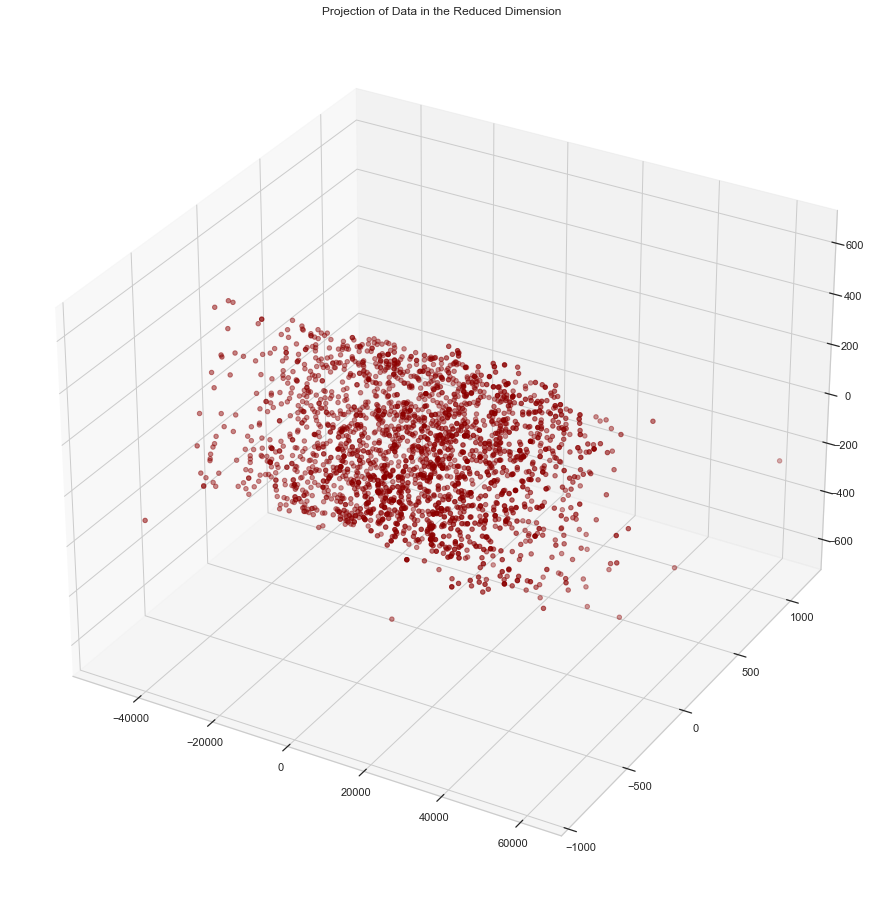

In [51]:
# 3D data visualisation in reduced dimension
x = p_components["pc1"]
y = p_components["pc2"]
z = p_components["pc3"]

fig = plt.figure(figsize=(18, 16))
ax = fig.add_subplot(111, projection = "3d")
ax.scatter(x, y, z, c = "darkred", marker = "o")
ax.set_title("Projection of Data in the Reduced Dimension")
plt.show()

## Model Building:

In [52]:
# KMeans clustering

from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer

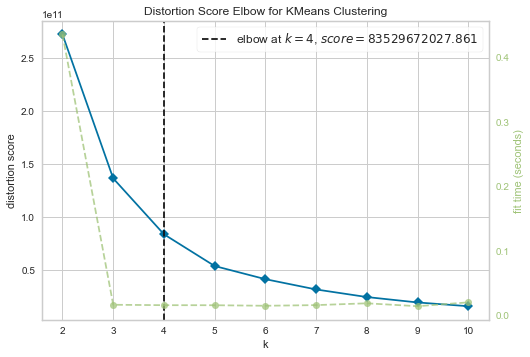

<AxesSubplot:title={'center':'Distortion Score Elbow for KMeans Clustering'}, xlabel='k', ylabel='distortion score'>

In [53]:
elbow = KElbowVisualizer(KMeans(), k=10)
elbow.fit(p_components)
elbow.show()

In [54]:
kmean = KMeans(n_clusters=4)

kmean.fit(p_components)

clusters = kmean.labels_

print(np.unique(clusters))

[0 1 2 3]


In [55]:
p_components

,pc1,pc2,pc3
0,6515.556538,-443.098173,-162.242103
1,-5289.055428,344.161429,88.409048
2,19983.447599,153.741032,-13.846138
3,-24984.958366,105.317796,179.491561
4,6661.626280,295.388754,52.486985
...,...,...,...
2224,9598.466776,-252.319217,134.225055
2225,12384.061436,261.319845,278.503043
2226,5359.216721,-343.744712,460.299342
2227,17616.356799,189.535430,121.068788


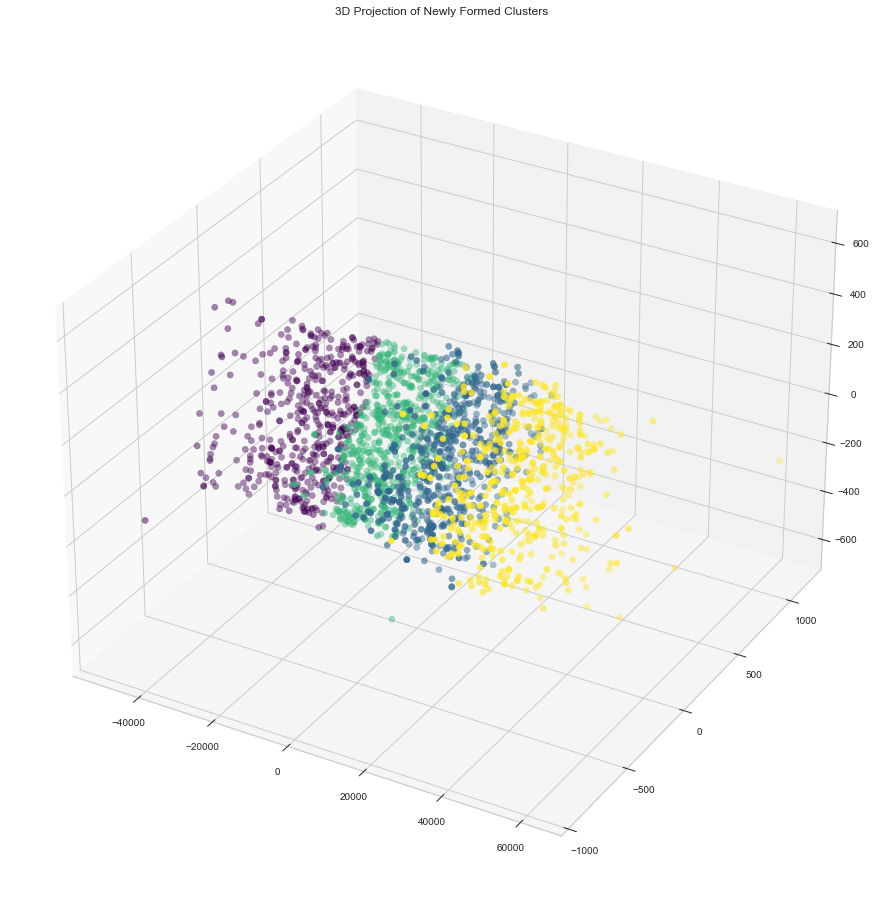

In [56]:
# Plot clusters
fig_3d = plt.figure(figsize=(18,16))
ax = plt.subplot(111, projection="3d", label="bla")
ax.scatter(x, y, z, s=40, c=clusters, marker="o", cmap='viridis')
ax.set_title("3D Projection of Newly Formed Clusters")
plt.show()

In [57]:
cluster1 = data.iloc[clusters == 0]
cluster2 = data.iloc[clusters == 1]
cluster3 = data.iloc[clusters == 2]
cluster4 = data.iloc[clusters == 3]

In [58]:
print(cluster1.Marital_Status.value_counts())
print("------------------------------------")
print(cluster1.Kids.value_counts())
print("------------------------------------")
print(f"min income: {min(cluster1.Income)}, max income: {max(cluster1.Income)}")


relationship    322
Single          173
Name: Marital_Status, dtype: int64
------------------------------------
1.0    309
0.0     94
2.0     84
3.0      8
Name: Kids, dtype: int64
------------------------------------
min income: 1730.0, max income: 33590.0


In [59]:
print(cluster2.Marital_Status.value_counts())
print("------------------------------------")
print(cluster2.Kids.value_counts())
print("------------------------------------")
print(f"min income: {min(cluster2.Income)}, max income: {max(cluster2.Income)}")

relationship    407
Single          205
Name: Marital_Status, dtype: int64
------------------------------------
1.0    367
0.0    139
2.0     94
3.0     12
Name: Kids, dtype: int64
------------------------------------
min income: 52614.0, max income: 71163.0


In [60]:
print(cluster3.Marital_Status.value_counts())
print("------------------------------------")
print(cluster3.Kids.value_counts())
print("------------------------------------")
print(f"min income: {min(cluster3.Income)}, max income: {max(cluster3.Income)}")

relationship    418
Single          251
Name: Marital_Status, dtype: int64
------------------------------------
1.0    346
2.0    225
0.0     69
3.0     29
Name: Kids, dtype: int64
------------------------------------
min income: 33622.0, max income: 52597.0


In [61]:
print(cluster4.Marital_Status.value_counts())
print("------------------------------------")
print(cluster4.Kids.value_counts())
print("------------------------------------")
print(f"min income: {min(cluster4.Income)}, max income: {max(cluster4.Income)}")

relationship    289
Single          164
Name: Marital_Status, dtype: int64
------------------------------------
0.0    331
1.0    101
2.0     17
3.0      4
Name: Kids, dtype: int64
------------------------------------
min income: 71232.0, max income: 113734.0


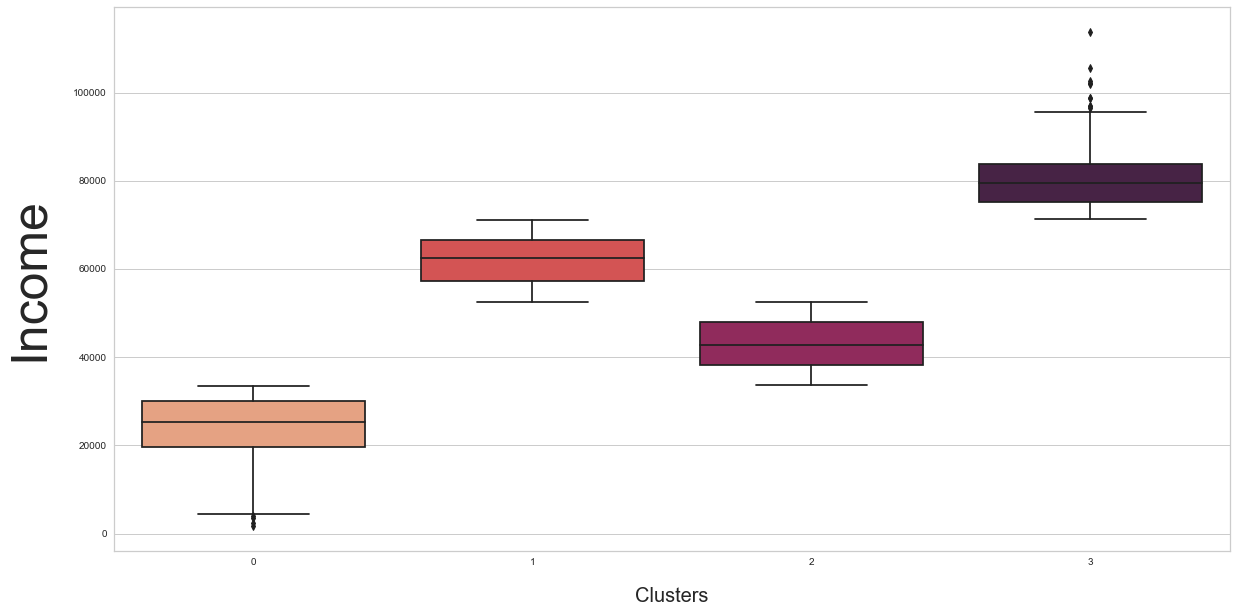

In [62]:
#Income
plt.figure(figsize=(20,10))

sns.boxplot(x=clusters, y = data['Income'],palette='rocket_r');
plt.xlabel('Clusters', fontsize=20, labelpad=20)
plt.ylabel('Income', fontsize=50, labelpad=20);

### From above boxplots we see that clusters are divided based upon income slabs.

<AxesSubplot:xlabel='Income', ylabel='Expenses'>

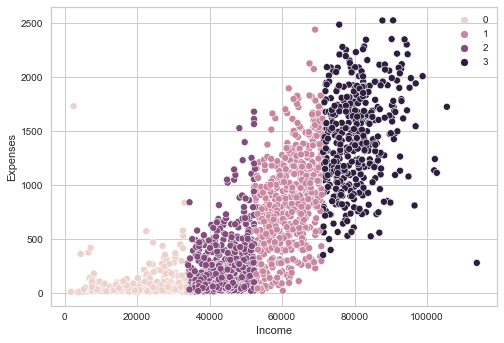

In [63]:
sns.scatterplot(x=data['Income'], y=data['Expenses'], hue=clusters)

## Spending Habits by Clusters

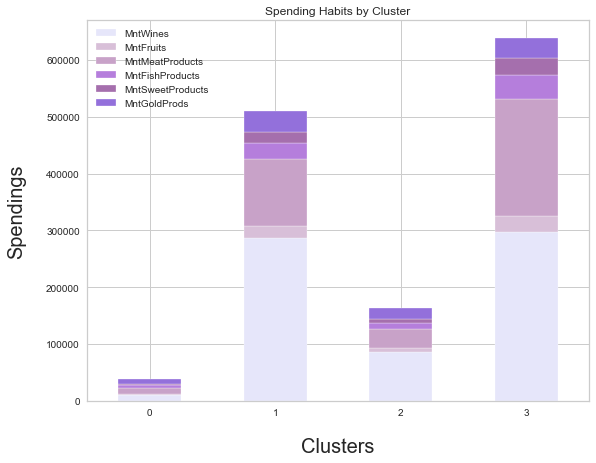

In [64]:
data["clusters"] = clusters

cluster_spendings = data.groupby('clusters')[['MntWines', 'MntFruits','MntMeatProducts',
                                                  'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']].sum()

cluster_spendings.plot(kind='bar', stacked=True, figsize=(9,7), color=[
  "#E6E6FA",
  "#D8BFD8",
  "#C8A2C8",
  "#B57EDC",
  "#A56FAD",
  "#9370DB"
])

plt.title('Spending Habits by Cluster')
plt.xlabel('Clusters', fontsize=20, labelpad=20)
plt.ylabel('Spendings', fontsize=20, labelpad=20);
plt.xticks(rotation=0, ha='center');

## Purchasing Habits by Clusters

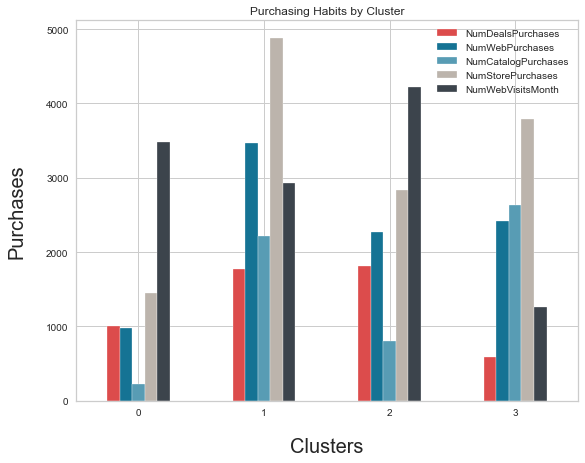

In [65]:
cluster_purchases = data.groupby('clusters')[['NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases',
                                                  'NumStorePurchases', 'NumWebVisitsMonth']].sum()

cluster_purchases.plot(kind='bar', color=['#dc4c4c','#157394','#589cb4','#bcb4ac','#3c444c'], figsize=(9,7))

plt.title('Purchasing Habits by Cluster')
plt.xlabel('Clusters', fontsize=20, labelpad=20)
plt.ylabel('Purchases', fontsize=20, labelpad=20);
plt.xticks(rotation=0, ha='center');

In [66]:
from sklearn.pipeline import make_pipeline
from sklearn.compose import ColumnTransformer
import sklearn.preprocessing


In [67]:
num_cols = ['Income','Age','Education','Marital_Status','Kids']
numeric_pipeline = make_pipeline(sklearn.preprocessing.StandardScaler())

In [68]:
# stack your pipelines in column transformer
transformer = ColumnTransformer(transformers=[('num',numeric_pipeline,num_cols),

                                             ])

In [69]:
transformer

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('standardscaler',
                                                  StandardScaler())]),
                                 ['Income', 'Age', 'Education',
                                  'Marital_Status', 'Kids'])])

In [70]:
transformed = transformer.fit_transform(df1)
print('Data has been Transformed')

Data has been Transformed


In [71]:
kmeans = KMeans(n_clusters=4, random_state=42)
df1['Clusters'] = kmeans.fit_predict(transformed)

In [72]:
df1.head()

,Income,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,...,AcceptedCmp1,AcceptedCmp2,Complain,Response,Age,Education,Marital_Status,Kids,day_engaged,Clusters
0,58138.0,58.0,635.0,88.0,546.0,172.0,88.0,88.0,3.0,8.0,...,0.0,0.0,0.0,1.0,58.0,0,0,0.0,849,3
1,46344.0,38.0,11.0,1.0,6.0,2.0,1.0,6.0,2.0,1.0,...,0.0,0.0,0.0,0.0,61.0,0,0,2.0,299,3
2,71613.0,26.0,426.0,49.0,127.0,111.0,21.0,42.0,1.0,8.0,...,0.0,0.0,0.0,0.0,50.0,0,1,0.0,498,1
3,26646.0,26.0,11.0,4.0,20.0,10.0,3.0,5.0,2.0,2.0,...,0.0,0.0,0.0,0.0,31.0,0,1,1.0,325,0
4,58293.0,94.0,173.0,43.0,118.0,46.0,27.0,15.0,5.0,5.0,...,0.0,0.0,0.0,0.0,34.0,0,1,1.0,347,0


In [73]:

df1 = df1[['Clusters', 'Education', 'Kids','Marital_Status','Income','Age']]


In [74]:
df1

,Clusters,Education,Kids,Marital_Status,Income,Age
0,3,0,0.0,0,58138.0,58.0
1,3,0,2.0,0,46344.0,61.0
2,1,0,0.0,1,71613.0,50.0
3,0,0,1.0,1,26646.0,31.0
4,0,0,1.0,1,58293.0,34.0
...,...,...,...,...,...,...
2235,1,0,1.0,1,61223.0,48.0
2236,0,0,3.0,1,64014.0,69.0
2237,3,0,0.0,0,56981.0,34.0
2238,1,0,1.0,1,69245.0,59.0


In [75]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.ensemble import GradientBoostingClassifier
# Import necessary libraries
from sklearn.ensemble import AdaBoostClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, classification_report
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [76]:
x = df1.drop('Clusters', axis=1)
y = df1['Clusters']

In [77]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)


knn classifier

In [78]:
knn_classifier = KNeighborsClassifier(n_neighbors=5)


In [79]:
!pip install scikit-learn
from sklearn.preprocessing import StandardScaler


[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [80]:
knn_pipeline = Pipeline([
    ('preprocessor', transformer),  # Apply your ColumnTransformer
    ('scaler', StandardScaler()),  # Standardize your features (optional but recommended for KNN)
    ('classifier', knn_classifier)  # KNN classifier
])


In [81]:
knn_pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Age', 'Education',
                                                   'Marital_Status',
                                                   'Kids'])])),
                ('scaler', StandardScaler()),
                ('classifier', KNeighborsClassifier())])

In [82]:
y_pred = knn_pipeline.predict(x_test)


In [83]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9865470852017937


Decision Tree Classifier

In [84]:
decision_tree_classifier = DecisionTreeClassifier(random_state=42)


In [85]:
decision_tree_pipeline = Pipeline([
    ('preprocessor', transformer),  # Apply your ColumnTransformer
    ('classifier', decision_tree_classifier)  # Decision Tree classifier
])

In [86]:
decision_tree_pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Age', 'Education',
                                                   'Marital_Status',
                                                   'Kids'])])),
                ('classifier', DecisionTreeClassifier(random_state=42))])

In [87]:
y_pred = decision_tree_pipeline.predict(x_test)


In [88]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9865470852017937


ADABoost Classifier

In [89]:
adaboost_classifier = AdaBoostClassifier(random_state=42)


In [90]:
adaboost_pipeline = Pipeline([
    ('preprocessor', transformer),  # Apply your ColumnTransformer
    ('classifier', adaboost_classifier)  # AdaBoost classifier
])


In [91]:
adaboost_pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Age', 'Education',
                                                   'Marital_Status',
                                                   'Kids'])])),
                ('classifier', AdaBoostClassifier(random_state=42))])

In [92]:
y_pred = adaboost_pipeline.predict(x_test)


In [93]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7040358744394619


Gradient Boosting

In [94]:
gradient_boosting_classifier = GradientBoostingClassifier(random_state=42)


In [95]:

gradient_boosting_pipeline = Pipeline([
    ('preprocessor', transformer),  # Apply your ColumnTransformer
    ('classifier', gradient_boosting_classifier)  # Gradient Boosting classifier
])


In [96]:
gradient_boosting_pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Age', 'Education',
                                                   'Marital_Status',
                                                   'Kids'])])),
                ('classifier', GradientBoostingClassifier(random_state=42))])

In [97]:
y_pred = gradient_boosting_pipeline.predict(x_test)


In [98]:

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9932735426008968


SVM

In [99]:
svm_classifier = SVC(kernel='linear', random_state=42)


In [100]:
svm_pipeline = Pipeline([
    ('preprocessor', transformer),  # Apply your ColumnTransformer
    ('classifier', svm_classifier)  # SVM classifier
])

In [101]:
svm_pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Age', 'Education',
                                                   'Marital_Status',
                                                   'Kids'])])),
                ('classifier', SVC(kernel='linear', random_state=42))])

In [102]:
y_pred = svm_pipeline.predict(x_test)


In [103]:

accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


Random Forest

In [104]:
random_forest_classifier = RandomForestClassifier(n_estimators=100)


In [105]:
random_forest_pipeline = Pipeline([
    ('preprocessor', transformer),  # Apply your ColumnTransformer
    ('classifier', random_forest_classifier)  # Random Forest classifier
])

In [106]:
random_forest_pipeline.fit(x_train, y_train)


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Age', 'Education',
                                                   'Marital_Status',
                                                   'Kids'])])),
                ('classifier', RandomForestClassifier())])

In [107]:
y_pred = random_forest_pipeline.predict(x_test)


In [108]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)


Accuracy: 0.9932735426008968


Logistic Regression

In [109]:
logistic_regression_classifier = LogisticRegression(random_state=42)

In [110]:
logistic_regression_pipeline = Pipeline([
    ('preprocessor', transformer),
    ('classifier', logistic_regression_classifier)
])

In [111]:
logistic_regression_pipeline.fit(x_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Age', 'Education',
                                                   'Marital_Status',
                                                   'Kids'])])),
                ('classifier', LogisticRegression(random_state=42))])

In [112]:
y_pred = logistic_regression_pipeline.predict(x_test)


In [113]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 1.0


In [114]:
model_accuracies = {
    'KNN': accuracy_score(y_test, knn_pipeline.predict(x_test)),
    'Decision Tree': accuracy_score(y_test, decision_tree_pipeline.predict(x_test)),
    'AdaBoost': accuracy_score(y_test, adaboost_pipeline.predict(x_test)),
    'Gradient Boosting': accuracy_score(y_test, gradient_boosting_pipeline.predict(x_test)),
    'SVM': accuracy_score(y_test, svm_pipeline.predict(x_test)),
    'Random Forest': accuracy_score(y_test, random_forest_pipeline.predict(x_test)),
    "Logistic Regression": accuracy_score(y_test, logistic_regression_pipeline.predict(x_test))

}

sorted_accuracies = sorted(model_accuracies.items(), key=lambda x: x[1], reverse=True)

for model, accuracy in sorted_accuracies:
    print(f'{model}: {accuracy:.4f}')

SVM: 1.0000
Logistic Regression: 1.0000
Gradient Boosting: 0.9933
Random Forest: 0.9933
KNN: 0.9865
Decision Tree: 0.9865
AdaBoost: 0.7040


Final model for deployment

In [115]:
from sklearn.linear_model import LogisticRegression


In [116]:
lr_model = LogisticRegression()

In [117]:
final_pipeline = make_pipeline(transformer, lr_model)

In [118]:
final_pipeline.fit(x_train, y_train)


Pipeline(steps=[('columntransformer',
                 ColumnTransformer(transformers=[('num',
                                                  Pipeline(steps=[('standardscaler',
                                                                   StandardScaler())]),
                                                  ['Income', 'Age', 'Education',
                                                   'Marital_Status',
                                                   'Kids'])])),
                ('logisticregression', LogisticRegression())])

Model Deployment

In [119]:
import pickle


In [120]:
filename = 'finalm.pkl' # create a variable with name you wanna give to the file
pickle.dump(final_pipeline, open(filename,'wb'))

In [121]:
!pip install -q streamlit
!npm install -g localtunnel -U


[notice] A new release of pip is available: 23.3.1 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip
'npm' is not recognized as an internal or external command,
operable program or batch file.


In [122]:
# importing necessary libraries
import pickle
import streamlit as st
import pandas as pd
import numpy as np

#load the model
classifier = pickle.load(open('finalm.pkl','rb'))


#page configuration
st.set_page_config(page_title = 'Customer Segmentation Web App', layout='centered')
st.title('Customer Segmentation Web App')

# customer segmentation function
def segment_customers(input_data):

    prediction=classifier.predict(pd.DataFrame(input_data, columns=['Income','Kids','Age','Marital_Status','Education']))
    print(prediction)
    pred_1 = 0
    if prediction == 1:
            pred_1 = 'cluster 1'

    elif prediction == 2:
            pred_1 = 'cluster 2'

    elif prediction == 3:
            pred_1 = 'cluster 3'

    elif prediction == 4:
            pred_1 = 'cluster 4'

    return pred_1
def main():

    Income = st.text_input("Type In The Household Income")
    Kids = st.radio ( "Select Number Of Kids In Household", ('0', '1','2','3') )
    Age = st.slider ( "Select Age", 18, 85 )
    Marital_Status = st.radio ( "Livig With Partner?", ('0', '1') )
    Education = st.radio ( "Select Education", ("0","1") )

    result = ""

    # when 'Predict' is clicked, make the prediction and store it
    if st.button("Segment Customer"):
        result=segment_customers([[Income,Kids,Age,Marital_Status,Education]])

    st.success(result)


if __name__ == '__main__':
        main ()


2024-04-05 11:39:05.957 
  command:

    streamlit run C:\New folder\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2024-04-05 11:39:05.959 Session state does not function when running a script without `streamlit run`


In [123]:
!wget -q -O - ipv4.icanhazip.com


'wget' is not recognized as an internal or external command,
operable program or batch file.


In [124]:
! streamlit run clu.py & npx localtunnel --port 8501


Usage: streamlit run [OPTIONS] TARGET [ARGS]...
Try 'streamlit run --help' for help.

Error: Invalid value: File does not exist: clu.py
'npx' is not recognized as an internal or external command,
operable program or batch file.
